## Baseline 
This is for the Project baseline, usas [] as model and get [] accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
test_dataset = pd.read_csv(".\data\\test.csv", sep=';')
training_dataset = pd.read_csv(".\data\\train.csv", sep=';')
validation_set = pd.read_csv(".\data\\validation.csv", sep=';')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\zijia\AppData\Local\Temp\ipykernel_42272\2906816233.py:1: SyntaxWarning: invalid escape sequence '\d'
  test_dataset = pd.read_csv(".\data\\test.csv", sep=';')
C:\Users\zijia\AppData\Local\Temp\ipykernel_42272\2906816233.py:2: SyntaxWarning: invalid escape sequence '\d'
  training_dataset = pd.read_csv(".\data\\train.csv", sep=';')
C:\Users\zijia\AppData\Local\Temp\ipykernel_42272\2906816233.py:3: SyntaxWarning: invalid escape sequence '\d'
  validation_set = pd.read_csv(".\data\\validation.csv", sep=';')


## Data exploration

In [13]:
print(training_dataset.head())
print("------------------------")
print(test_dataset.head())
print("------------------------")
print(validation_set.head())

      screen_name                                               text  \
0      imranyebot                             YEA now that note GOOD   
1          zawvrk  Listen to This Charming Man by The Smiths  htt...   
2        zawarbot  wish i can i would be seeing other hoes on the...   
3  ahadsheriffbot  The decade in the significantly easier schedul...   
4   kevinhookebot  "Theim class=\"alignnone size-full wp-image-60...   

  account.type class_type  
0          bot     others  
1        human      human  
2          bot     others  
3          bot     others  
4          bot        rnn  
------------------------
      screen_name                                               text  \
0          zawvrk  justin timberlake really one of the goats if y...   
1    narendramodi  Thank you @PMBhutan for your gracious prayers ...   
2     ahadsheriff  Theory: the number of red lights you will hit ...   
3  AINarendraModi  Respects on the Upt of the I good with the peo...   
4      kevinho

In [ ]:
print(training_dataset)

<bound method NDFrame.first of           screen_name                                               text  \
0          imranyebot                             YEA now that note GOOD   
1              zawvrk  Listen to This Charming Man by The Smiths  htt...   
2            zawarbot  wish i can i would be seeing other hoes on the...   
3      ahadsheriffbot  The decade in the significantly easier schedul...   
4       kevinhookebot  "Theim class=\"alignnone size-full wp-image-60...   
...               ...                                                ...   
20707  AINarendraModi  Met on the Abversion of our science for the co...   
20708  AINarendraModi  Land for their during the opportunity to the p...   
20709      DeepDrumpf  @TayandYou doesn't have a clue. You're right. ...   
20710           jaden           Me And My Bestie https://t.co/vPq2iDkWZm   
20711   kevinhookebot  "Thead has a generate existing the Sparching f...   

      account.type class_type  
0              bot     o

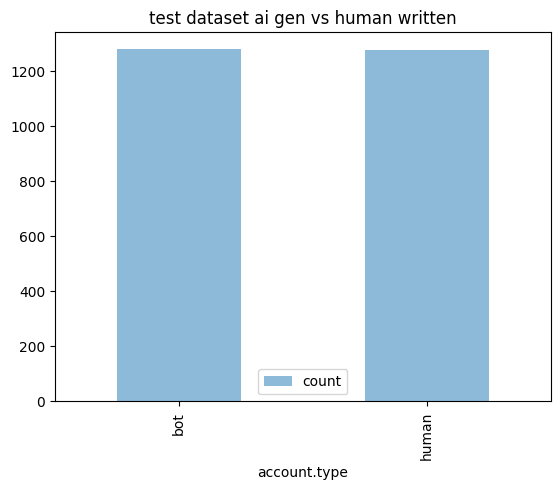

In [7]:

test_dataset['account.type'].value_counts().plot(kind='bar', legend=True, alpha=.5)
plt.title("test dataset ai gen vs human written")
plt.show()

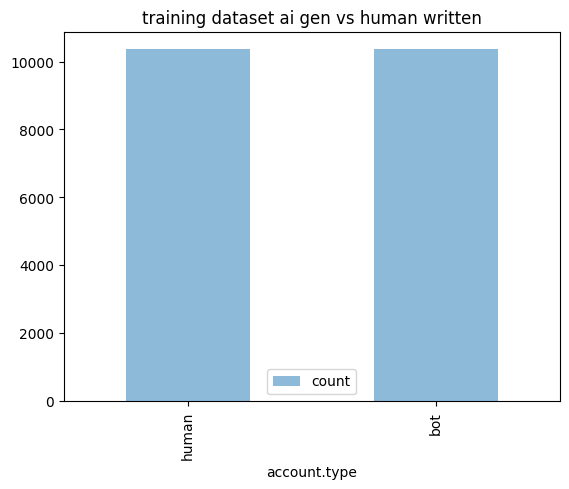

In [8]:

training_dataset['account.type'].value_counts().plot(kind='bar', legend=True, alpha=.5)
plt.title("training dataset ai gen vs human written")
plt.show()

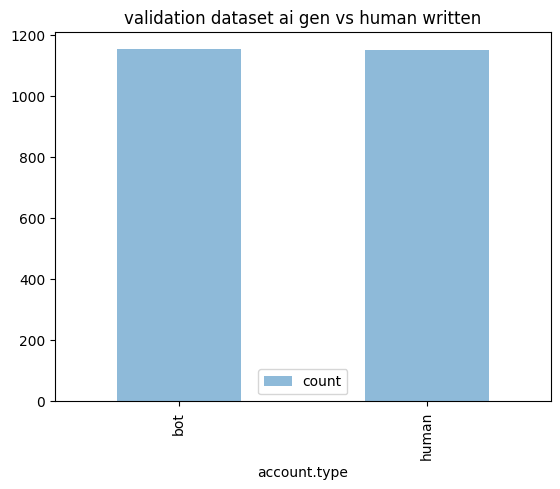

In [26]:
validation_set['account.type'].value_counts().plot(kind='bar', legend=True, alpha=.5)
plt.title("validation dataset ai gen vs human written")
plt.show()

## Data Processing

In [28]:
def load_and_preprocess(file_path, separator=';'):
    # Load the dataset (adjust separator if it is a standard comma ',')
    df = pd.read_csv(file_path, sep=separator)
    
    # 1. Map the 'account.type' column to binary labels
    label_mapping = {'human': 0, 'bot': 1}
    df['label'] = df['account.type'].str.lower().map(label_mapping)
    
    # 2. Keep only the text and the new label column
    df = df[['text', 'label']]
    
    # 3. Drop any rows with missing text or labels just to be safe
    df = df.dropna()
    
    return df

In [31]:
print("Loading datasets...")
train_df = load_and_preprocess(".\data\\train.csv", separator=';')
val_df = load_and_preprocess(".\data\\validation.csv", separator=';')
test_df = load_and_preprocess(".\data\\test.csv", separator=';')

print("\n--- Data Shapes ---")
print(f"Train:      {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test:       {test_df.shape}")

# Preview the cleaned training data
print("\n--- Cleaned Training Data Preview ---")
print(train_df.head())

Loading datasets...

--- Data Shapes ---
Train:      (20712, 2)
Validation: (2302, 2)
Test:       (2558, 2)

--- Cleaned Training Data Preview ---
                                                text  label
0                             YEA now that note GOOD      1
1  Listen to This Charming Man by The Smiths  htt...      0
2  wish i can i would be seeing other hoes on the...      1
3  The decade in the significantly easier schedul...      1
4  "Theim class=\"alignnone size-full wp-image-60...      1


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\zijia\AppData\Local\Temp\ipykernel_42272\1287009048.py:2: SyntaxWarning: invalid escape sequence '\d'
  train_df = load_and_preprocess(".\data\\train.csv", separator=';')
C:\Users\zijia\AppData\Local\Temp\ipykernel_42272\1287009048.py:3: SyntaxWarning: invalid escape sequence '\d'
  val_df = load_and_preprocess(".\data\\validation.csv", separator=';')
C:\Users\zijia\AppData\Local\Temp\ipykernel_42272\1287009048.py:4: SyntaxWarning: invalid escape sequence '\d'
  test_df = load_and_preprocess(".\data\\test.csv", separator=';')


## Feature extraction

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
vectorizer = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2), 
    stop_words='english',
    min_df = 5
)

In [36]:
X_train_tfidf = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label']

# 4. ONLY TRANSFORM the validation and test data
# It maps the validation/test text to the vocabulary it learned from step 3. 
# Any brand new words in val/test are ignored.
X_val_tfidf = vectorizer.transform(val_df['text'])
y_val = val_df['label']

X_test_tfidf = vectorizer.transform(test_df['text'])
y_test = test_df['label']

# 5. Review the Results
print("\n--- Feature Extraction Complete ---")
print(f"Vocabulary Size: {len(vectorizer.vocabulary_)}")
print(f"Training Matrix Shape:   {X_train_tfidf.shape}")
print(f"Validation Matrix Shape: {X_val_tfidf.shape}")
print(f"Test Matrix Shape:       {X_test_tfidf.shape}")



--- Feature Extraction Complete ---
Vocabulary Size: 7088
Training Matrix Shape:   (20712, 7088)
Validation Matrix Shape: (2302, 7088)
Test Matrix Shape:       (2558, 7088)


## Model Build

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

In [38]:
# 1. Train the Baseline Model
baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

print("Training the baseline model on the new training set...")
baseline_model.fit(X_train_tfidf, y_train)
print("Training complete!\n")

# 2. Make Predictions on the TEST Data
# We strictly use the X_test_tfidf matrix we generated previously
print("Evaluating on the official Test Set...")
y_test_pred = baseline_model.predict(X_test_tfidf)
y_test_pred_proba = baseline_model.predict_proba(X_test_tfidf)[:, 1]

# 3. Calculate Final Evaluation Metrics
f1_test = f1_score(y_test, y_test_pred)
auc_roc_test = roc_auc_score(y_test, y_test_pred_proba)

print("--- Official Test Set Metrics ---")
print(f"F1-Score: {f1_test:.4f}")
print(f"AUC-ROC:  {auc_roc_test:.4f}\n")

# Detailed classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=['Human (0)', 'Bot (1)']))

# Confusion Matrix
print("--- Confusion Matrix ---")
cm_test = confusion_matrix(y_test, y_test_pred)
print(f"True Negatives (Human correctly identified): {cm_test[0][0]}")
print(f"False Positives (Human misclassified as Bot): {cm_test[0][1]}")
print(f"False Negatives (Bot misclassified as Human): {cm_test[1][0]}")
print(f"True Positives (Bot correctly identified):    {cm_test[1][1]}")

Training the baseline model on the new training set...
Training complete!

Evaluating on the official Test Set...
--- Official Test Set Metrics ---
F1-Score: 0.7880
AUC-ROC:  0.8664

--- Detailed Classification Report ---
              precision    recall  f1-score   support

   Human (0)       0.81      0.71      0.76      1278
     Bot (1)       0.74      0.84      0.79      1280

    accuracy                           0.77      2558
   macro avg       0.78      0.77      0.77      2558
weighted avg       0.78      0.77      0.77      2558

--- Confusion Matrix ---
True Negatives (Human correctly identified): 906
False Positives (Human misclassified as Bot): 372
False Negatives (Bot misclassified as Human): 206
True Positives (Bot correctly identified):    1074


## Evaluation

### Drop 80% of the AI-gen records(more practical distribute) and re-evaluate

In [39]:
human_test_df = test_df[test_df['label'] == 0]
ai_test_df = test_df[test_df['label'] == 1]

# 2. Randomly drop 80% of the AI records (by keeping 20%)
# random_state=42 ensures reproducibility so you can document this exact split in your report
ai_test_df_reduced = ai_test_df.sample(frac=0.20, random_state=42)

# 3. Recombine into a new, highly imbalanced test set and shuffle it
test_df_imbalanced = pd.concat([human_test_df, ai_test_df_reduced]).sample(frac=1, random_state=42)

print(f"--- Data Alteration Complete ---")
print(f"Original Test Set Size:   {test_df.shape[0]}")
print(f"New Imbalanced Test Size: {test_df_imbalanced.shape[0]}")
print(f"New Class Distribution:\n{test_df_imbalanced['label'].value_counts()}\n")

# ==========================================
# 4. FEATURE EXTRACTION (Transform Only)
# ==========================================
# We use the vectorizer that was fit on the training data earlier
X_test_imbalanced_tfidf = vectorizer.transform(test_df_imbalanced['text'])
y_test_imbalanced = test_df_imbalanced['label']

# ==========================================
# 5. RE-EVALUATION
# ==========================================
print("Evaluating baseline model on the highly imbalanced test set...\n")
y_pred_imbalanced = baseline_model.predict(X_test_imbalanced_tfidf)
y_pred_proba_imbalanced = baseline_model.predict_proba(X_test_imbalanced_tfidf)[:, 1]

# 6. Calculate Metrics
f1_imb = f1_score(y_test_imbalanced, y_pred_imbalanced)
auc_roc_imb = roc_auc_score(y_test_imbalanced, y_pred_proba_imbalanced)

print("--- Imbalanced Test Set Metrics ---")
print(f"F1-Score: {f1_imb:.4f}")
print(f"AUC-ROC:  {auc_roc_imb:.4f}\n")

# Detailed classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_test_imbalanced, y_pred_imbalanced, target_names=['Human (0)', 'Bot (1)']))

# Confusion Matrix
print("--- Confusion Matrix ---")
cm_imb = confusion_matrix(y_test_imbalanced, y_pred_imbalanced)
print(f"True Negatives (Human correctly identified): {cm_imb[0][0]}")
print(f"False Positives (Human misclassified as Bot): {cm_imb[0][1]}")
print(f"False Negatives (Bot misclassified as Human): {cm_imb[1][0]}")
print(f"True Positives (Bot correctly identified):    {cm_imb[1][1]}")

--- Data Alteration Complete ---
Original Test Set Size:   2558
New Imbalanced Test Size: 1534
New Class Distribution:
label
0    1278
1     256
Name: count, dtype: int64

Evaluating baseline model on the highly imbalanced test set...

--- Imbalanced Test Set Metrics ---
F1-Score: 0.5048
AUC-ROC:  0.8641

--- Detailed Classification Report ---
              precision    recall  f1-score   support

   Human (0)       0.95      0.71      0.81      1278
     Bot (1)       0.36      0.83      0.50       256

    accuracy                           0.73      1534
   macro avg       0.66      0.77      0.66      1534
weighted avg       0.86      0.73      0.76      1534

--- Confusion Matrix ---
True Negatives (Human correctly identified): 906
False Positives (Human misclassified as Bot): 372
False Negatives (Bot misclassified as Human): 44
True Positives (Bot correctly identified):    212


### Result shows baseline model is overfitting on balanced training set